In [10]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram

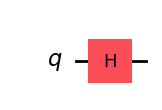

In [11]:

# Create a circuit with one qubit
circuit = QuantumCircuit(1)

# Add a Hadamard (H) gate on qubit 0, to create a superposition
circuit.h(0)

# Draw the circuit diagram. Delete "mpl" to get a text diagram.
circuit.draw("mpl")

In [12]:
# Now simulate the circuit by calculating the effect on state vectors.
# Set the initial state of the simulator to |0>
# The state vector has two coefficients, both 0
state = Statevector.from_int(0, 2)

# Apply the circuit to the state
state = state.evolve(circuit)

# Display using latex. This requires the pylatexenc module.
# Omit "latex" to get a numerical (not algebraic) view of the state vector.
state.draw("latex")

<IPython.core.display.Latex object>

In [13]:
# A different way of dislaying the state, again using latex
from qiskit.visualization import array_to_latex

array_to_latex(state)

<IPython.core.display.Latex object>

In [14]:
# The whole circuit is a unitary operator, which we can display.

U = Operator(circuit)
array_to_latex(U)

<IPython.core.display.Latex object>

In [15]:
# Or less beautifully:
U.data
# The format is a little bit odd. 0.j means the imaginary part is 0
# 0 is being displayed with a decimal point but no trailing 0
# j is used for the square root of -1, instead of i

array([[ 0.70710678+0.j,  0.70710678+0.j],
       [ 0.70710678+0.j, -0.70710678+0.j]])

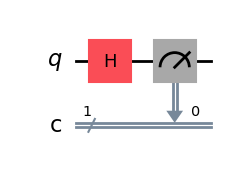

In [16]:
# Now reconstruct the circuit and add a measurement
# The second parameter of QuantumCircuit is the number of classical bits
circuit = QuantumCircuit(1,1)
circuit.h(0)

# The first list is the qubits to measure,
# the second list is the classical bits where the results go
circuit.measure([0],[0])
circuit.draw("mpl")

In [32]:
# We will need to transpile the circuit into QASM instructions for the back end

# Use BasicSimulator
backend = BasicSimulator()

# Compile / transpile
qc_compiled = transpile(circuit, backend)

# Run the circuit on the simulator.
# We've set the number of repeats of the circuit
# to be 1024, which is the default.
# The qubits start in state |0>
job_sim = backend.run(qc_compiled, shots=1024)

# Grab the results from the job (this doesn't produce any output).
result_sim = job_sim.result()

In [18]:
# The simplest way to see the results of the simulation
counts = result_sim.get_counts(qc_compiled)
print(counts)

# The results are not exactly half 0 and half 1, but should be close.
# There will be different results each time the previous cell is run.

{'0': 506, '1': 518}


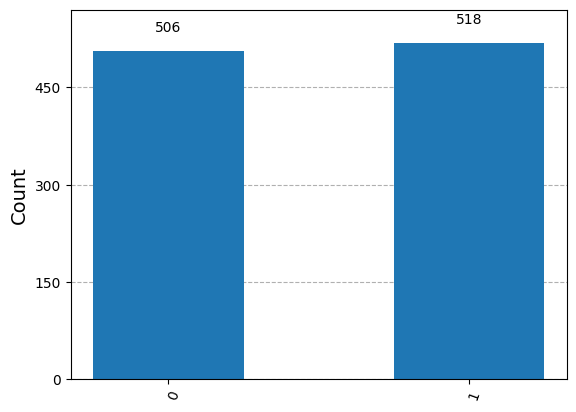

In [19]:
# We can also produce a graph

plot_histogram(counts)

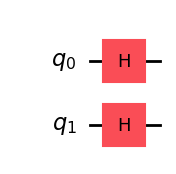

In [20]:
# Now let's move on to two qubits.
# Apply H to both qubits and see what we get.

circuit = QuantumCircuit(2)
circuit.h(0)
circuit.h(1)

circuit.draw("mpl")

In [21]:
state = Statevector.from_int(0, 4) # 4 is the number of basis states on 2 qubits
state = state.evolve(circuit)
state.draw("latex")

<IPython.core.display.Latex object>

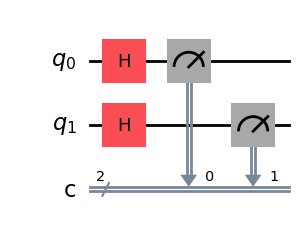

In [22]:
# Now measurement. This time we construct the measurement part
# of the circuit separately and then combine it with the first circuit.

# A new circuit with 2 qubits and 2 classical bits
meas = QuantumCircuit(2, 2)

# Map the quantum measurement to the classical bits
meas.measure(range(2), range(2))

# The Qiskit circuit object supports composition.
# Here the meas has to be first and front=True (putting it before)
# as compose must put a smaller circuit into a larger one.
qc = meas.compose(circuit, range(2), front=True)

qc.draw("mpl")

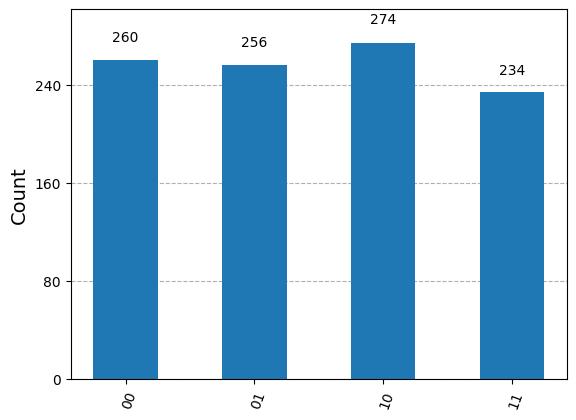

In [23]:
# Simulate again, using the same back end
qc_compiled = transpile(qc, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
plot_histogram(counts)

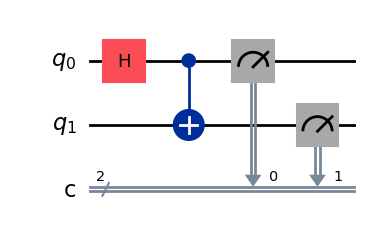

In [24]:
# Now for some entanglement.
# Construct a Bell state and measure both qubits to see that
# both measurements give the same result.

circuit = QuantumCircuit(2,2)
circuit.h(0)
circuit.cx(0,1) # cx means CNOT because it's a controlled version of x (negation)
circuit.measure(range(2),range(2))
circuit.draw("mpl")

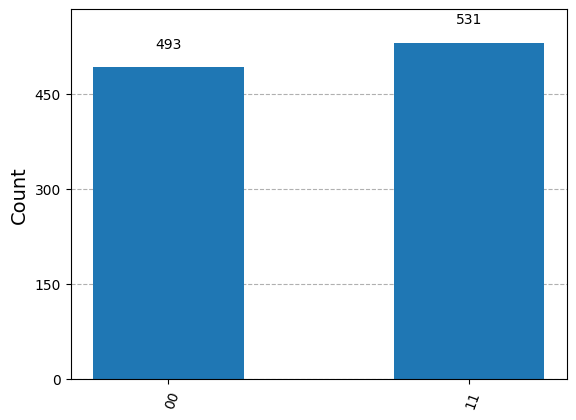

In [25]:
qc_compiled = transpile(circuit, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
plot_histogram(counts)


--- Phi+ ---
State Vector:


<>:14: SyntaxWarning: invalid escape sequence '\{'
<>:14: SyntaxWarning: invalid escape sequence '\}'
<>:14: SyntaxWarning: invalid escape sequence '\{'
<>:14: SyntaxWarning: invalid escape sequence '\}'
/tmp/ipykernel_5339/1067695576.py:14: SyntaxWarning: invalid escape sequence '\{'
  display(array_to_latex(final_state, prefix=f'|\{{\text{{{name}}}\}}\rangle = '))
/tmp/ipykernel_5339/1067695576.py:14: SyntaxWarning: invalid escape sequence '\}'
  display(array_to_latex(final_state, prefix=f'|\{{\text{{{name}}}\}}\rangle = '))


<IPython.core.display.Latex object>

Circuit Diagram (with measurements):


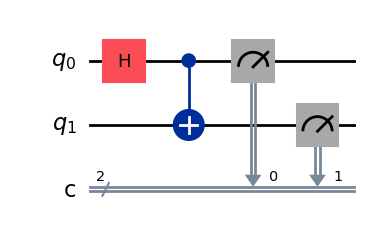

Measurement Results:


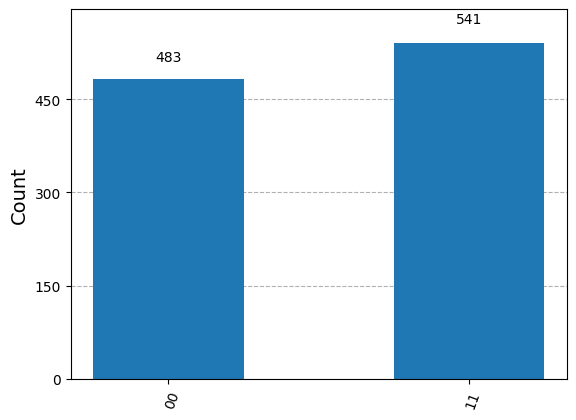


--- Phi- ---
State Vector:


<IPython.core.display.Latex object>

Circuit Diagram (with measurements):


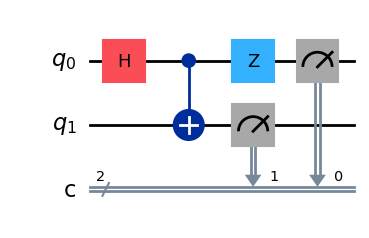

Measurement Results:


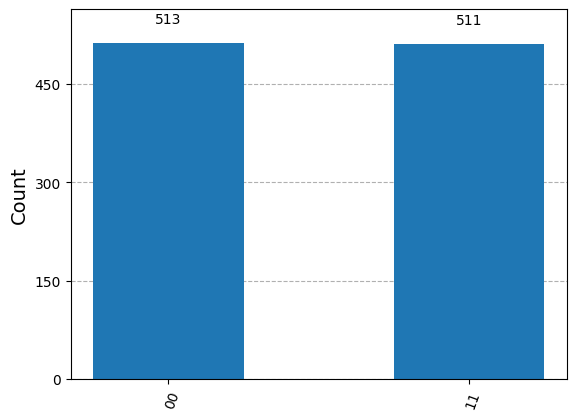


--- Psi+ ---
State Vector:


<IPython.core.display.Latex object>

Circuit Diagram (with measurements):


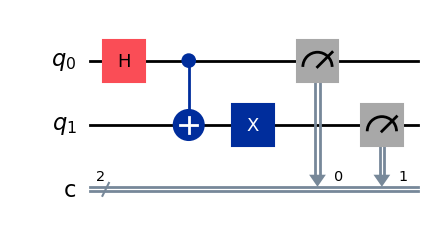

Measurement Results:


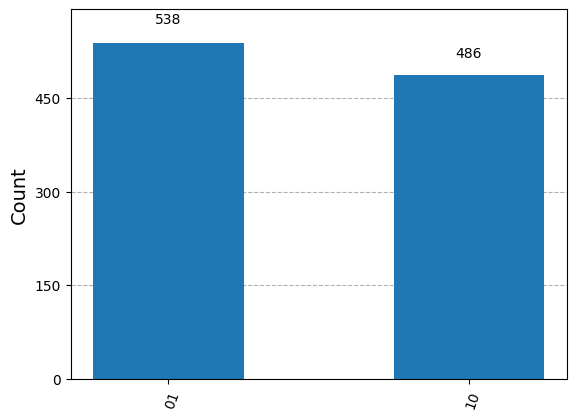


--- Psi- ---
State Vector:


<IPython.core.display.Latex object>

Circuit Diagram (with measurements):


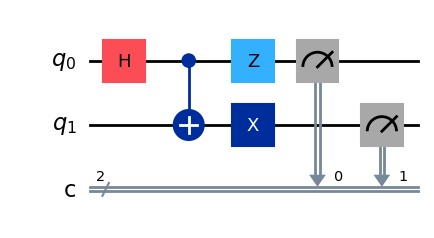

Measurement Results:


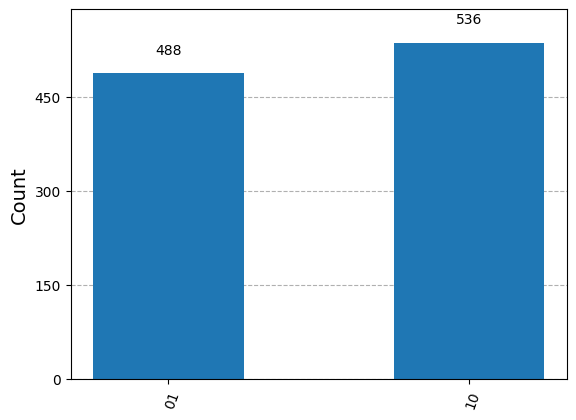

In [30]:
# EXERCISE

def create_and_analyze_bell_state(name, circuit_func):
    print(f"\n--- {name} ---")

    # Create the circuit without measurements for state vector analysis
    qc_state = QuantumCircuit(2)
    circuit_func(qc_state)

    # Display the state vector
    initial_state = Statevector.from_int(0, 4) # 4 is for 2 qubits
    final_state = initial_state.evolve(qc_state)
    print("State Vector:")
    display(array_to_latex(final_state, prefix=f'|\{{\text{{{name}}}\}}\rangle = '))

    # Create the circuit with measurements for simulation
    qc_meas = QuantumCircuit(2, 2)
    circuit_func(qc_meas)
    qc_meas.measure(range(2), range(2))
    print("Circuit Diagram (with measurements):")
    display(qc_meas.draw("mpl"))

    # Simulate and plot histogram
    qc_compiled = transpile(qc_meas, backend)
    job_sim = backend.run(qc_compiled, shots=1024)
    result_sim = job_sim.result()
    counts = result_sim.get_counts(qc_compiled)
    print("Measurement Results:")
    display(plot_histogram(counts))

# Bell State 1: Phi+ = 1/sqrt(2) (|00> + |11>)
def bell_phi_plus(qc):
    qc.h(0)
    qc.cx(0, 1)

create_and_analyze_bell_state("Phi+", bell_phi_plus)

# Bell State 2: Phi- = 1/sqrt(2) (|00> - |11>)
def bell_phi_minus(qc):
    qc.h(0)
    qc.cx(0, 1)
    qc.z(0) # Apply Z to qubit 0 to flip the sign of |11>

create_and_analyze_bell_state("Phi-", bell_phi_minus)

# Bell State 3: Psi+ = 1/sqrt(2) (|01> + |10>)
def bell_psi_plus(qc):
    qc.h(0)
    qc.cx(0, 1)
    qc.x(1) # Apply X to qubit 1 to transform |00> to |01> and |11> to |10>

create_and_analyze_bell_state("Psi+", bell_psi_plus)

# Bell State 4: Psi- = 1/sqrt(2) (|01> - |10>)
def bell_psi_minus(qc):
    qc.h(0)
    qc.cx(0, 1)
    qc.x(1) # First get Psi+
    qc.z(0) # Apply Z to qubit 0 to flip the sign of |10> component (01 - 10)

create_and_analyze_bell_state("Psi-", bell_psi_minus)


In [27]:
# EXERCISE

# The GHZ state on any number of qubits has the form  1/sqrt(2) ( |00...0> + |11...1> )

# The Bell state 1/sqrt(2) ( |00> + |11> ) is the case for two qubits.

# Write code to construct a circuit that produces a GHZ state for any given number of qubits. (change ghz number)

# Try simulating the circuit, with measurements. How many qubits can the simulator handle in a reasonable time?

GHZ Circuit for 5 qubits:


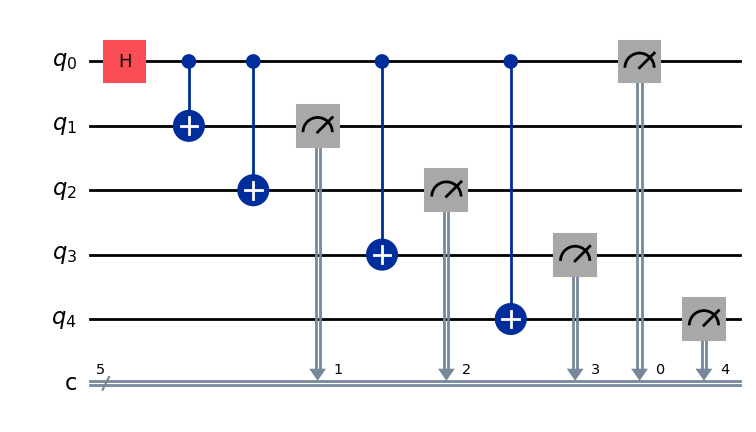

Measurement Results for 3-qubit GHZ state:


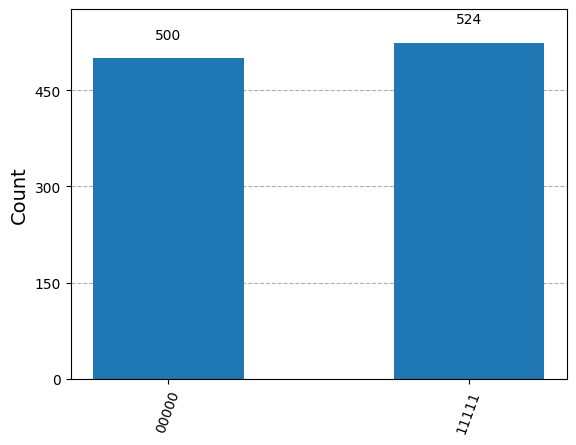

In [34]:
def create_ghz_circuit(num_qubits):
    qc = QuantumCircuit(num_qubits, num_qubits)
    qc.h(0)
    for i in range(1, num_qubits):
        qc.cx(0, i)
    qc.measure(range(num_qubits), range(num_qubits))
    return qc

# Example for 3 qubits
num_qubits_ghz = 5
ghz_circuit_3_qubits = create_ghz_circuit(num_qubits_ghz)
print(f"GHZ Circuit for {num_qubits_ghz} qubits:")
display(ghz_circuit_3_qubits.draw("mpl"))

# Simulate the GHZ circuit for 3 qubits
qc_compiled_ghz = transpile(ghz_circuit_3_qubits, backend)
job_sim_ghz = backend.run(qc_compiled_ghz, shots=1024)
result_sim_ghz = job_sim_ghz.result()
counts_ghz = result_sim_ghz.get_counts(qc_compiled_ghz)
print("Measurement Results for 3-qubit GHZ state:")
display(plot_histogram(counts_ghz))

### Simulator Performance for GHZ States

The `BasicSimulator` (and most classical simulators) struggles with increasing numbers of qubits due to the exponential growth of the Hilbert space. The state vector of `n` qubits has $2^n$ complex amplitudes.

*   **Small Qubit Counts (e.g., 2-10 qubits):** Simulation is generally fast and efficient.
*   **Medium Qubit Counts (e.g., 10-20 qubits):** Simulation becomes noticeably slower, and memory requirements increase significantly. You might start to experience delays.
*   **Larger Qubit Counts (e.g., 20-30 qubits):** Simulation can take minutes to hours and require substantial RAM (gigabytes to terabytes). At some point, it might exceed the available memory or time limits of a typical Colab environment.
*   **Beyond 30-40 qubits:** Classical simulation becomes practically impossible on standard hardware, as it would require petabytes of memory and an unfeasibly long time. This is where real quantum hardware is essential.

For a GHZ state, since it's a maximally entangled state, the complexity of representing and evolving the state vector scales exponentially with the number of qubits. Trying to simulate a GHZ state for, say, 25 qubits might already be challenging within a Colab environment due to memory and computational constraints.